[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kshitijrajsharma/deeplearning_scafolding/blob/master/vegetation_segmentation.ipynb)

# Vegetation segmentation: UNet on RGB (+ NDVI + shade)

Tiles are `(6, 250, 250)` uint8 arrays: channels `R, G, B, NDVI, shade, label`.
Label is `0 = background`, `1 = tall`, `2 = flat`. Toggle `USE_NDVI` / `USE_SHADE` / `USE_AUG` below.

In [1]:
# Uncomment on a fresh runtime (e.g. Google Colab) to install dependencies.
# !pip install torch lightning segmentation-models-pytorch torchmetrics kornia scikit-learn matplotlib numpy pandas geopandas rasterio

In [2]:
import glob
import os

import geopandas as gpd
import kornia.augmentation as K
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio.features
import segmentation_models_pytorch as smp
import torch
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.transform import from_origin
from shapely.geometry import shape
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score, jaccard_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassF1Score, MulticlassJaccardIndex

CLASS_NAMES = ["background", "tall", "flat"]  # label values 0, 1, 2
RESOLUTION = 0.08  # metres per pixel (20 m tile / 250 px)
TILE_CRS = "EPSG:25832"  # ETRS89 / UTM 32N; tile names encode the SW corner
LABEL_CMAP = ListedColormap(["#2b2b2b", "#2ca02c", "#bcbd22"])  # bg, tall, flat


def input_channels(use_ndvi, use_shade):
    return [0, 1, 2] + ([3] if use_ndvi else []) + ([4] if use_shade else [])

/home/krschap/code/personal/deeplearning_scafolding/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

In [3]:
DATA = "data/dataset"
USE_NDVI = True    # add the NDVI channel
USE_SHADE = True   # add the shade channel
USE_AUG = True     # kornia horizontal/vertical flips during training
EPOCHS = 50
BATCH_SIZE = 16
LR = 1e-3
NUM_WORKERS = 4
PATIENCE = 10
SEED = 42
OUT = "outputs"

os.makedirs(OUT, exist_ok=True)
L.seed_everything(SEED, workers=True)
CHANNELS = input_channels(USE_NDVI, USE_SHADE)
IN_CHANNELS = len(CHANNELS)
IN_CHANNELS

Seed set to 42


5

## Training samples

RGB, NDVI, the shade mask, and the label for a few training tiles, so you can see what each channel adds.

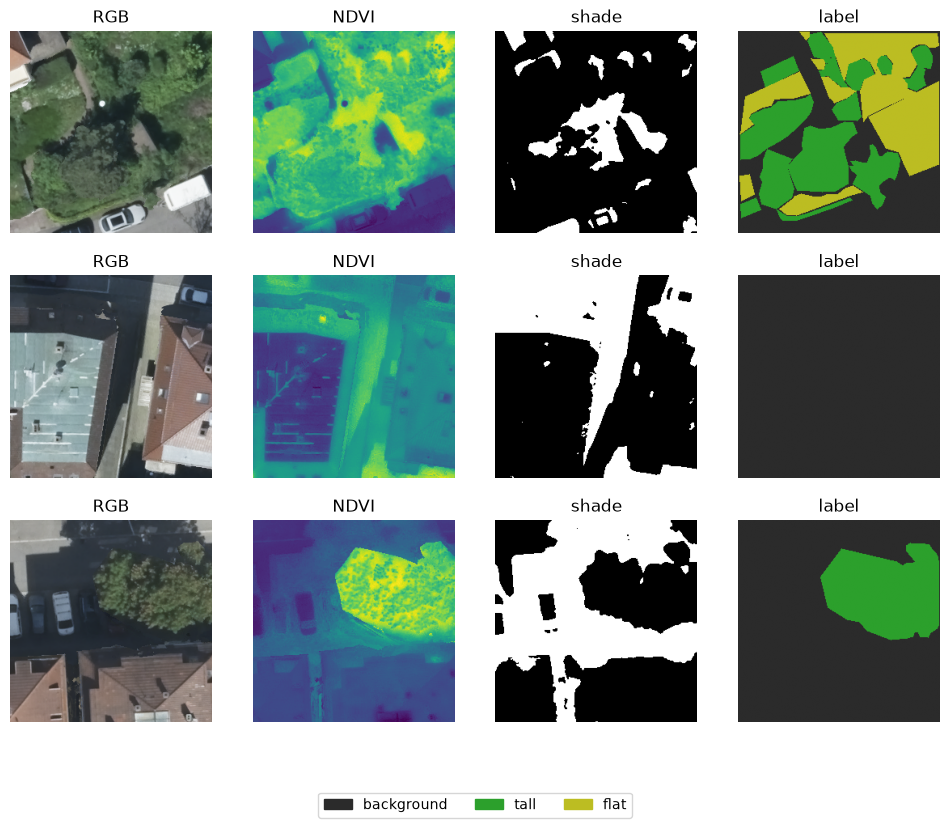

In [4]:
n = 3
files = sorted(glob.glob(os.path.join(DATA, "train", "*.npy")))[:n]
fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n))
for row, file in enumerate(files):
    tile = np.load(file).astype(np.float32)
    rgb = tile[:3].transpose(1, 2, 0) / 255.0
    panels = [
        (rgb, "RGB", {}),
        (tile[3], "NDVI", {"cmap": "viridis"}),
        (tile[4], "shade", {"cmap": "gray"}),
        (tile[5], "label", {"cmap": LABEL_CMAP, "vmin": 0, "vmax": len(CLASS_NAMES) - 1}),
    ]
    for ax, (data, title, kw) in zip(axes[row], panels):
        ax.imshow(data, **kw)
        ax.set_title(title)
        ax.axis("off")
handles = [Patch(color=LABEL_CMAP(i), label=name) for i, name in enumerate(CLASS_NAMES)]
fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES))
plt.show()

## Class distribution per split

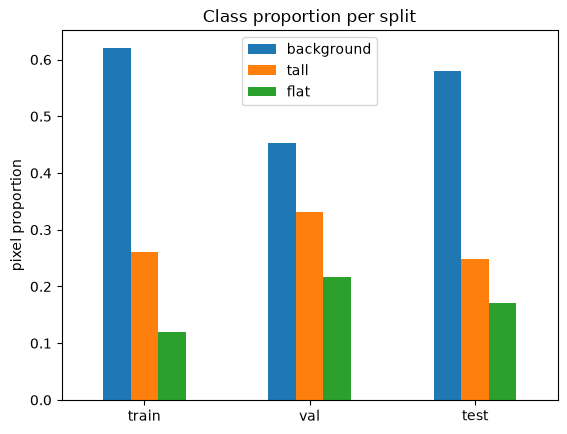

In [5]:
def proportions(split):
    counts = np.zeros(len(CLASS_NAMES), dtype=np.int64)
    for file in glob.glob(os.path.join(DATA, split, "*.npy")):
        label = np.load(file, mmap_mode="r")[5].astype(int).ravel()
        counts += np.bincount(label, minlength=len(CLASS_NAMES))
    return counts / counts.sum()


dist = pd.DataFrame({s: proportions(s) for s in ["train", "val", "test"]}, index=CLASS_NAMES)
dist.T.plot.bar(title="Class proportion per split", ylabel="pixel proportion", rot=0)
plt.show()

## Dataset

In [6]:
class NpyDataset(Dataset):
    """Tiles of shape (6, H, W): R, G, B, NDVI, shade, label."""

    def __init__(self, split_dir, use_ndvi=True, use_shade=True):
        self.files = sorted(glob.glob(os.path.join(split_dir, "*.npy")))
        self.channels = input_channels(use_ndvi, use_shade)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        tile = np.load(self.files[index]).astype(np.float32)
        image = torch.from_numpy(tile[self.channels] / 255.0)
        label = torch.from_numpy(tile[5]).long()
        return image, label

## Model

mIoU and macro F1 are tracked; macro F1 is the early-stopping target. Per-epoch loss is tracked for the loss curve.

In [7]:
class SegModel(L.LightningModule):
    def __init__(self, in_channels, num_classes=3, lr=1e-3, use_aug=True):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.use_aug = use_aug
        self.net = smp.Unet(
            encoder_name="resnet18",
            encoder_weights=None,
            in_channels=in_channels,
            classes=num_classes,
        )
        self.loss = nn.CrossEntropyLoss()
        self.aug = K.AugmentationSequential(
            K.RandomHorizontalFlip(p=0.5),
            K.RandomVerticalFlip(p=0.5),
            data_keys=["input", "mask"],
        )
        self.train_f1 = MulticlassF1Score(num_classes, average="macro")
        self.val_f1 = MulticlassF1Score(num_classes, average="macro")
        self.val_iou = MulticlassJaccardIndex(num_classes, average="macro")
        self.train_loss = MeanMetric()
        self.val_loss = MeanMetric()
        self.train_history = []
        self.val_history = []
        self.train_loss_history = []
        self.val_loss_history = []

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, _):
        image, label = batch
        if self.use_aug:
            image, mask = self.aug(image, label.unsqueeze(1).float())
            label = mask.squeeze(1).long()
        logits = self(image)
        loss = self.loss(logits, label)
        self.train_f1.update(logits.argmax(1), label)
        self.train_loss.update(loss)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.train_history.append(self.train_f1.compute().item())
        self.train_loss_history.append(self.train_loss.compute().item())
        self.train_f1.reset()
        self.train_loss.reset()

    def validation_step(self, batch, _):
        image, label = batch
        logits = self(image)
        loss = self.loss(logits, label)
        self.val_f1.update(logits.argmax(1), label)
        self.val_iou.update(logits.argmax(1), label)
        self.val_loss.update(loss)
        self.log("val_loss", loss, prog_bar=True)

    def on_validation_epoch_end(self):
        f1 = self.val_f1.compute().item()
        self.log("val_f1", f1, prog_bar=True)
        self.log("val_iou", self.val_iou.compute().item(), prog_bar=True)
        self.val_history.append(f1)
        self.val_loss_history.append(self.val_loss.compute().item())
        self.val_f1.reset()
        self.val_iou.reset()
        self.val_loss.reset()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

## Data loaders

In [8]:
class VegDataModule(L.LightningDataModule):
    def __init__(self, data_dir, use_ndvi=True, use_shade=True, batch_size=16, num_workers=4):
        super().__init__()
        self.data_dir = data_dir
        self.use_ndvi = use_ndvi
        self.use_shade = use_shade
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.in_channels = len(input_channels(use_ndvi, use_shade))

    def _loader(self, split, shuffle):
        dataset = NpyDataset(os.path.join(self.data_dir, split), self.use_ndvi, self.use_shade)
        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=self.num_workers,
            pin_memory=torch.cuda.is_available(),
        )

    def train_dataloader(self):
        return self._loader("train", shuffle=True)

    def val_dataloader(self):
        return self._loader("val", shuffle=False)

    def test_dataloader(self):
        return self._loader("test", shuffle=False)


data = VegDataModule(DATA, USE_NDVI, USE_SHADE, BATCH_SIZE, NUM_WORKERS)
test_loader = data.test_dataloader()
data.in_channels

5

## Train

Early stopping watches `val_f1` with patience 10; the best checkpoint is saved.

In [9]:
model = SegModel(in_channels=data.in_channels, lr=LR, use_aug=USE_AUG)
early_stop = L.pytorch.callbacks.EarlyStopping(monitor="val_f1", mode="max", patience=PATIENCE)
checkpoint = L.pytorch.callbacks.ModelCheckpoint(monitor="val_f1", mode="max", dirpath=OUT, filename="best")
trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    callbacks=[early_stop, checkpoint],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
)
trainer.fit(model, datamodule=data)
print("optimizer lr:", trainer.optimizers[0].param_groups[0]["lr"])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/krschap/code/personal/deeplearning_scafolding/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4090 Laptop GPU') that has Tensor Cores. To properly utilize them, you

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net        │ Unet                   │ 14.3 M │ train │     0 │
│ 1 │ loss       │ CrossEntropyLoss       │      0 │ train │     0 │
│ 2 │ aug        │ AugmentationSequential │      0 │ train │     0 │
│ 3 │ train_f1   │ MulticlassF1Score      │      0 │ train │     0 │
│ 4 │ val_f1     │ MulticlassF1Score      │      0 │ train │     0 │
│ 5 │ val_iou    │ MulticlassJaccardIndex │      0 │ train │     0 │
│ 6 │ train_loss │ MeanMetric             │      0 │ train │     0 │
│ 7 │ val_loss   │ MeanMetric             │      0 │ train │     0 │
└───┴────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 14.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 14.3 M                                                                                               
Total estimated model params size (MB): 57.339                                                                     
Modules in train mode: 149                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/krschap/code/personal/deeplearning_scafolding/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


/home/krschap/code/personal/deeplearning_scafolding/.venv/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

optimizer lr: 0.001


## Accuracy and loss curves

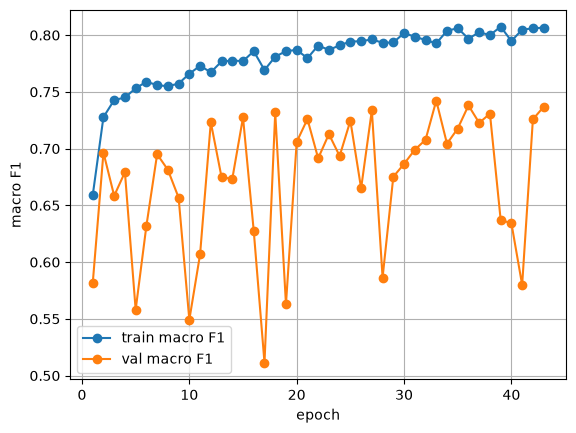

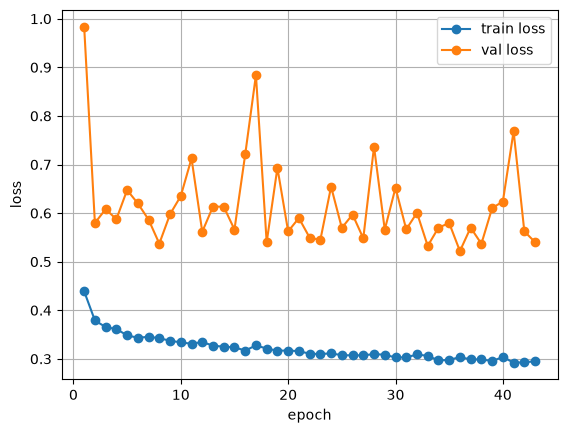

In [10]:
def plot_curve(train_values, val_values, ylabel):
    epochs = range(1, len(train_values) + 1)
    plt.figure()
    plt.plot(epochs, train_values, marker="o", label=f"train {ylabel}")
    plt.plot(epochs, val_values, marker="o", label=f"val {ylabel}")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_curve(model.train_history, model.val_history, "macro F1")
plot_curve(model.train_loss_history, model.val_loss_history, "loss")

## Evaluate best checkpoint on test

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
best = SegModel.load_from_checkpoint(checkpoint.best_model_path).eval().to(device)

preds, targets = [], []
with torch.no_grad():
    for image, label in test_loader:
        logits = best(image.to(device))
        preds.append(logits.argmax(1).cpu().numpy().ravel())
        targets.append(label.numpy().ravel())
preds = np.concatenate(preds)
targets = np.concatenate(targets)

labels = list(range(len(CLASS_NAMES)))
print(classification_report(targets, preds, labels=labels, target_names=CLASS_NAMES, digits=4))
print("macro F1 :", round(f1_score(targets, preds, labels=labels, average="macro", zero_division=0), 4))
print("mIoU     :", round(jaccard_score(targets, preds, labels=labels, average="macro", zero_division=0), 4))
per_class_iou = jaccard_score(targets, preds, labels=labels, average=None, zero_division=0)
print("per-class IoU:", dict(zip(CLASS_NAMES, per_class_iou.round(4))))

              precision    recall  f1-score   support

  background     0.9542    0.9304    0.9422  26165304
        tall     0.6728    0.7265    0.6986  11223308
        flat     0.5651    0.5474    0.5561   7673888

    accuracy                         0.8144  45062500
   macro avg     0.7307    0.7347    0.7323  45062500
weighted avg     0.8179    0.8144    0.8158  45062500

macro F1 : 0.7323
mIoU     : 0.6042
per-class IoU: {'background': np.float64(0.8906), 'tall': np.float64(0.5368), 'flat': np.float64(0.3851)}


## Confusion matrix

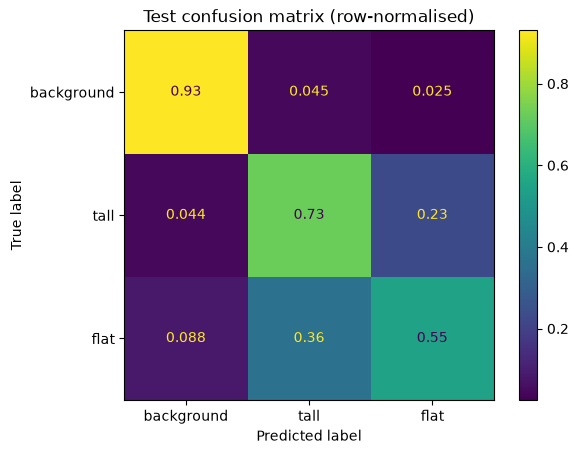

In [12]:
ConfusionMatrixDisplay.from_predictions(targets, preds, labels=labels, display_labels=CLASS_NAMES, normalize="true")
plt.title("Test confusion matrix (row-normalised)")
plt.show()

## Test tiles: image / mask / prediction

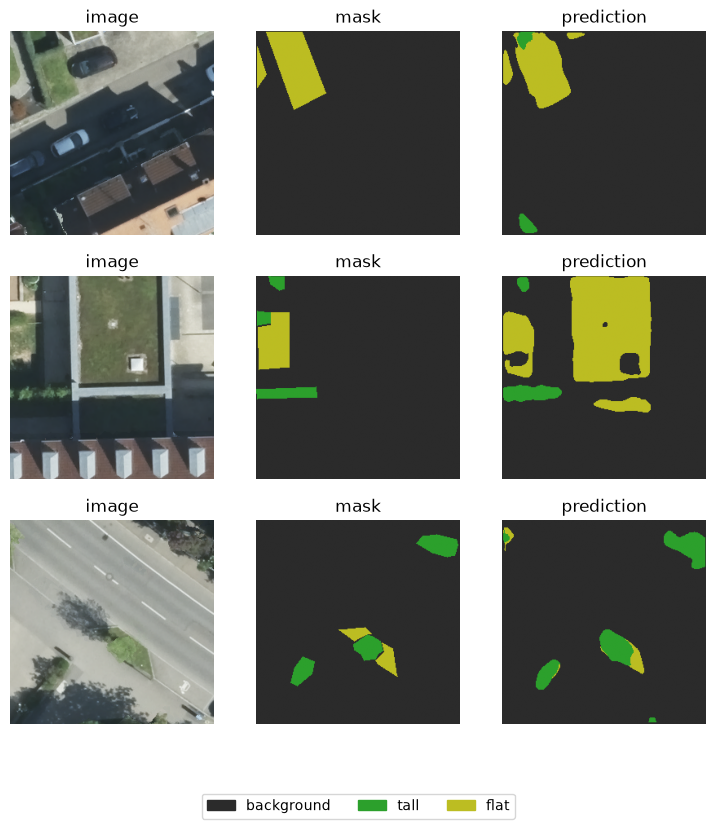

In [13]:
images, masks = next(iter(test_loader))
with torch.no_grad():
    grid_preds = best(images.to(device)).argmax(1).cpu()

n = 3
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for row in range(n):
    rgb = images[row, :3].permute(1, 2, 0).numpy()
    for ax, (data, title) in zip(axes[row], [(rgb, "image"), (masks[row], "mask"), (grid_preds[row], "prediction")]):
        ax.imshow(data, cmap=LABEL_CMAP, vmin=0, vmax=len(CLASS_NAMES) - 1)
        ax.set_title(title)
        ax.axis("off")
handles = [Patch(color=LABEL_CMAP(i), label=name) for i, name in enumerate(CLASS_NAMES)]
fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES))
plt.show()

## Vectorize predictions to GeoJSON (EPSG:25832)

Picks a spatially contiguous block of tiles (the per-tile split breaks adjacency within test, so the block is taken from all splits), georeferences each prediction with a 0.08 m/px affine transform, vectorizes with `rasterio.features.shapes`, and writes the polygons to GeoJSON.

In [14]:
def adjacent_tiles(files, n_tiles, step=20):
    coords = {}
    for file in files:
        east, north = (int(v) for v in os.path.splitext(os.path.basename(file))[0].split("_")[1:3])
        coords[(east, north)] = file
    block = []
    for seed in coords:
        seen, queue = [seed], [seed]
        while queue and len(seen) < n_tiles:
            east, north = queue.pop(0)
            for nb in ((east + step, north), (east - step, north), (east, north + step), (east, north - step)):
                if nb in coords and nb not in seen:
                    seen.append(nb)
                    queue.append(nb)
        if len(seen) > len(block):
            block = seen
        if len(block) >= n_tiles:
            break
    return [coords[c] for c in block[:n_tiles]]


def tile_polygons(file, prediction):
    name = os.path.splitext(os.path.basename(file))[0]
    east, north = (int(v) for v in name.split("_")[1:3])
    transform = from_origin(east, north + prediction.shape[0] * RESOLUTION, RESOLUTION, RESOLUTION)
    return [
        {"geometry": shape(geom), "class": CLASS_NAMES[int(value)], "tile": name}
        for geom, value in rasterio.features.shapes(prediction.astype("int32"), transform=transform)
        if value != 0
    ]


records = []
for file in adjacent_tiles(sorted(glob.glob(os.path.join(DATA, "*", "*.npy"))), 6):
    tile = np.load(file).astype(np.float32)
    image = torch.from_numpy(tile[CHANNELS] / 255.0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = best(image).argmax(1)[0].cpu().numpy()
    records += tile_polygons(file, pred)

features = gpd.GeoDataFrame(records, crs=TILE_CRS)
features.to_file(os.path.join(OUT, "predictions.geojson"), driver="GeoJSON")
print(len(features), "polygons ->", os.path.join(OUT, "predictions.geojson"))

81 polygons -> outputs/predictions.geojson
